In [1]:
"""
MPS311/439: Interactive Linear Regression Visualizations
=========================================================
Lecture 2: Predicting the Future with Lines

This notebook contains interactive visualizations to help understand
the key concepts of linear regression.

Run each cell to see the interactive plots!
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# VISUALIZATION 1: Interactive Line Fitting
# ============================================================================
print("=" * 70)
print("VISUALIZATION 1: Interactive Line Fitting")
print("=" * 70)
print("Adjust the sliders to change w0 (bias) and w1 (weight)")
print("Watch how the line changes and observe the MSE!")
print()

# Generate sample data
X_simple = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_simple = 2.5 * X_simple + 5 + np.random.randn(10) * 2

def plot_line_fit(w0, w1):
    """Interactive plot showing line fit and MSE"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left plot: Data and fitted line
    ax1.scatter(X_simple, y_simple, color='#2E86AB', s=100, 
                alpha=0.7, edgecolors='black', linewidth=1.5, label='Actual data')
    
    # Predicted line
    y_pred = w1 * X_simple + w0
    ax1.plot(X_simple, y_pred, 'r-', linewidth=2.5, label=f'ŷ = {w1:.2f}x + {w0:.2f}')
    
    # Draw residuals
    for i in range(len(X_simple)):
        ax1.plot([X_simple[i], X_simple[i]], [y_simple[i], y_pred[i]], 
                'k--', alpha=0.3, linewidth=1)
    
    ax1.set_xlabel('x (Feature)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('y (Target)', fontsize=12, fontweight='bold')
    ax1.set_title('Linear Regression: Fit the Line!', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Residuals
    residuals = y_simple - y_pred
    colors = ['#E63946' if r > 0 else '#06A77D' for r in residuals]
    ax2.bar(range(len(residuals)), residuals, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.set_xlabel('Data Point Index', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Residual (y - ŷ)', fontsize=12, fontweight='bold')
    ax2.set_title('Residuals (Errors)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Calculate and display MSE
    mse = np.mean(residuals**2)
    fig.suptitle(f'Mean Squared Error (MSE) = {mse:.2f}', 
                 fontsize=16, fontweight='bold', color='#F77F00')
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(plot_line_fit,
         w0=FloatSlider(min=-10, max=20, step=0.5, value=5, description='Bias (w₀)'),
         w1=FloatSlider(min=-2, max=6, step=0.1, value=2.5, description='Weight (w₁)'))



VISUALIZATION 1: Interactive Line Fitting
Adjust the sliders to change w0 (bias) and w1 (weight)
Watch how the line changes and observe the MSE!



interactive(children=(FloatSlider(value=5.0, description='Bias (w₀)', max=20.0, min=-10.0, step=0.5), FloatSli…

<function __main__.plot_line_fit(w0, w1)>


VISUALIZATION 2: The Loss Function Landscape
This 3D surface shows how MSE changes with different w0 and w1 values
The red star shows the optimal parameters!



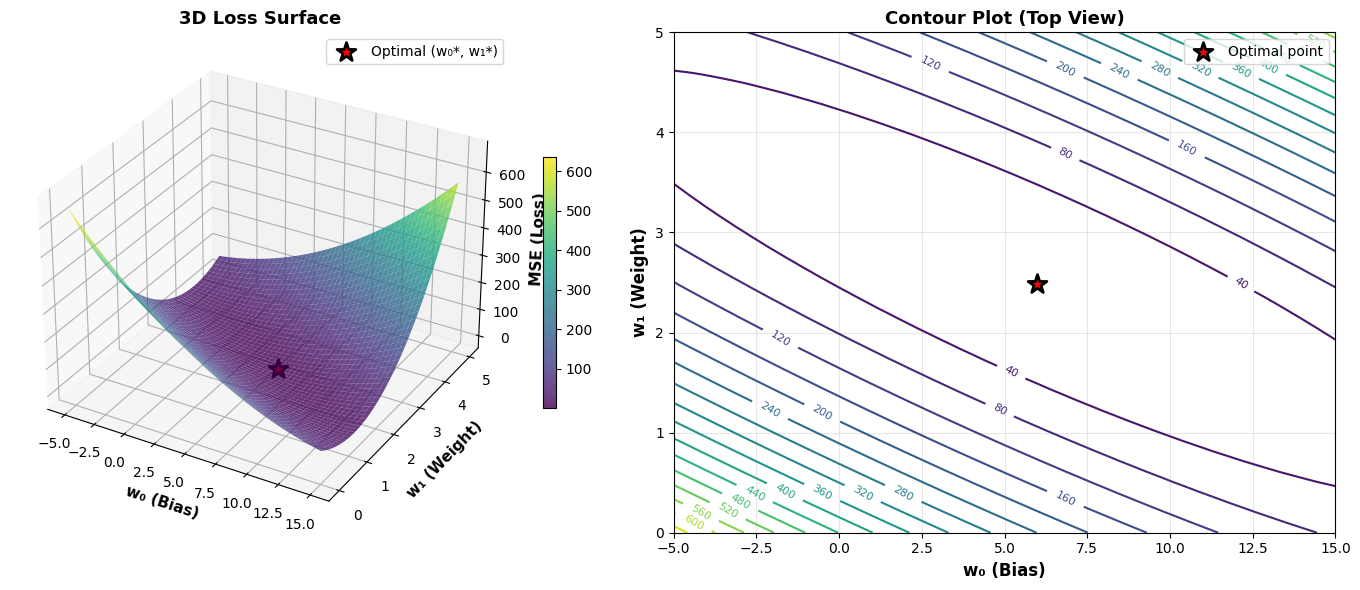

Optimal parameters: w₀* = 5.972, w₁* = 2.486

VISUALIZATION 3: Gradient Descent in Action
Watch how gradient descent finds the optimal parameters step by step!



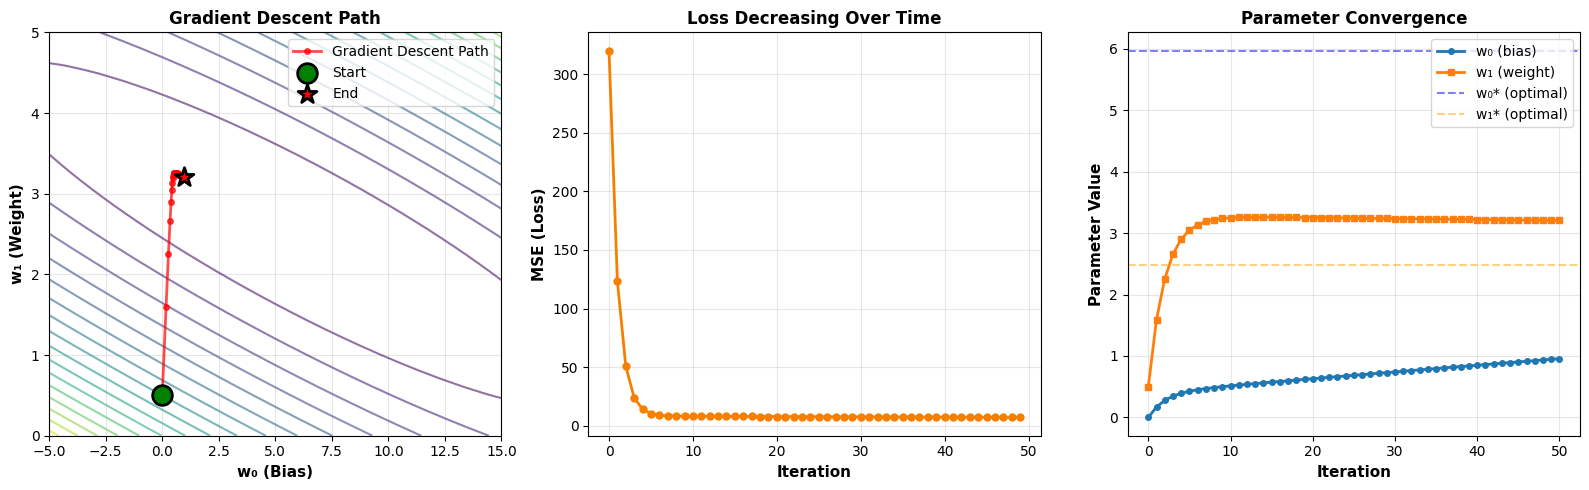

In [7]:

# ============================================================================
# VISUALIZATION 2: Loss Function Surface (3D)
# ============================================================================
print("\n" + "=" * 70)
print("VISUALIZATION 2: The Loss Function Landscape")
print("=" * 70)
print("This 3D surface shows how MSE changes with different w0 and w1 values")
print("The red star shows the optimal parameters!")
print()

# Compute optimal parameters using normal equation
X_design = np.column_stack([np.ones_like(X_simple), X_simple])
w_optimal = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_simple

# Create grid of w0 and w1 values
w0_range = np.linspace(-5, 15, 50)
w1_range = np.linspace(0, 5, 50)
W0, W1 = np.meshgrid(w0_range, w1_range)

# Compute MSE for each combination
MSE = np.zeros_like(W0)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        y_pred = W1[i, j] * X_simple + W0[i, j]
        MSE[i, j] = np.mean((y_simple - y_pred)**2)

# Create 3D plot
fig = plt.figure(figsize=(14, 6))

# 3D surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W0, W1, MSE, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.scatter([w_optimal[0]], [w_optimal[1]], 
            [np.mean((y_simple - (w_optimal[1] * X_simple + w_optimal[0]))**2)],
            color='red', s=200, marker='*', edgecolors='black', linewidth=2,
            label='Optimal (w₀*, w₁*)')
ax1.set_xlabel('w₀ (Bias)', fontsize=11, fontweight='bold')
ax1.set_ylabel('w₁ (Weight)', fontsize=11, fontweight='bold')
ax1.set_zlabel('MSE (Loss)', fontsize=11, fontweight='bold')
ax1.set_title('3D Loss Surface', fontsize=13, fontweight='bold')
ax1.legend()
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(W0, W1, MSE, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.scatter(w_optimal[0], w_optimal[1], color='red', s=200, marker='*', 
            edgecolors='black', linewidth=2, zorder=5, label='Optimal point')
ax2.set_xlabel('w₀ (Bias)', fontsize=12, fontweight='bold')
ax2.set_ylabel('w₁ (Weight)', fontsize=12, fontweight='bold')
ax2.set_title('Contour Plot (Top View)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal parameters: w₀* = {w_optimal[0]:.3f}, w₁* = {w_optimal[1]:.3f}")


# ============================================================================
# VISUALIZATION 3: Gradient Descent Animation
# ============================================================================
print("\n" + "=" * 70)
print("VISUALIZATION 3: Gradient Descent in Action")
print("=" * 70)
print("Watch how gradient descent finds the optimal parameters step by step!")
print()

def gradient_descent_path(X, y, alpha=0.001, iterations=50):
    """Run gradient descent and record the path"""
    X_design = np.column_stack([np.ones_like(X), X])
    n = len(X)
    
    # Start from a random point
    w = np.array([0.0, 0.5])
    path = [w.copy()]
    losses = []
    
    for _ in range(iterations):
        y_pred = X_design @ w
        gradient = -2/n * X_design.T @ (y - y_pred)
        w = w - alpha * gradient
        path.append(w.copy())
        losses.append(np.mean((y - y_pred)**2))
    
    return np.array(path), losses

# Run gradient descent
path, losses = gradient_descent_path(X_simple, y_simple, alpha=0.005, iterations=50)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Contour with gradient descent path
ax = axes[0]
contour = ax.contour(W0, W1, MSE, levels=20, cmap='viridis', alpha=0.6)
ax.plot(path[:, 0], path[:, 1], 'ro-', markersize=4, linewidth=2, 
        label='Gradient Descent Path', alpha=0.7)
ax.scatter(path[0, 0], path[0, 1], color='green', s=200, marker='o',
           edgecolors='black', linewidth=2, zorder=5, label='Start')
ax.scatter(path[-1, 0], path[-1, 1], color='red', s=200, marker='*',
           edgecolors='black', linewidth=2, zorder=5, label='End')
ax.set_xlabel('w₀ (Bias)', fontsize=11, fontweight='bold')
ax.set_ylabel('w₁ (Weight)', fontsize=11, fontweight='bold')
ax.set_title('Gradient Descent Path', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Loss over iterations
ax = axes[1]
ax.plot(losses, 'o-', color='#F77F00', linewidth=2, markersize=5)
ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax.set_ylabel('MSE (Loss)', fontsize=11, fontweight='bold')
ax.set_title('Loss Decreasing Over Time', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Parameter convergence
ax = axes[2]
ax.plot(path[:, 0], 'o-', label='w₀ (bias)', linewidth=2, markersize=4)
ax.plot(path[:, 1], 's-', label='w₁ (weight)', linewidth=2, markersize=4)
ax.axhline(y=w_optimal[0], color='blue', linestyle='--', alpha=0.5, label='w₀* (optimal)')
ax.axhline(y=w_optimal[1], color='orange', linestyle='--', alpha=0.5, label='w₁* (optimal)')
ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax.set_ylabel('Parameter Value', fontsize=11, fontweight='bold')
ax.set_title('Parameter Convergence', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [3]:

# ============================================================================
# VISUALIZATION 4: Effect of Learning Rate
# ============================================================================
print("\n" + "=" * 70)
print("VISUALIZATION 4: Learning Rate Impact")
print("=" * 70)
print("See how different learning rates affect convergence!")
print()

def compare_learning_rates(alpha):
    """Show gradient descent with different learning rates"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Run gradient descent
    path, losses = gradient_descent_path(X_simple, y_simple, alpha=alpha, iterations=50)
    
    # Plot 1: Path on contour
    ax = axes[0]
    contour = ax.contour(W0, W1, MSE, levels=20, cmap='viridis', alpha=0.5)
    ax.plot(path[:, 0], path[:, 1], 'ro-', markersize=5, linewidth=2, alpha=0.7)
    ax.scatter(path[0, 0], path[0, 1], color='green', s=150, marker='o',
               edgecolors='black', linewidth=2, zorder=5, label='Start')
    ax.scatter(w_optimal[0], w_optimal[1], color='red', s=200, marker='*',
               edgecolors='black', linewidth=2, zorder=5, label='Optimal')
    ax.set_xlabel('w₀ (Bias)', fontsize=11, fontweight='bold')
    ax.set_ylabel('w₁ (Weight)', fontsize=11, fontweight='bold')
    ax.set_title(f'Path with α = {alpha}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Loss curve
    ax = axes[1]
    ax.plot(losses, 'o-', color='#F77F00', linewidth=2, markersize=5)
    ax.set_xlabel('Iteration', fontsize=11, fontweight='bold')
    ax.set_ylabel('MSE (Loss)', fontsize=11, fontweight='bold')
    ax.set_title(f'Loss Convergence with α = {alpha}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, max(losses) * 1.1])
    ax.grid(True, alpha=0.3)
    
    # Check convergence
    if len(losses) > 1:
        if losses[-1] < losses[0] * 0.1:
            status = "✓ Converged well!"
            color = '#06A77D'
        elif losses[-1] < losses[0]:
            status = "⚠ Converging slowly"
            color = '#F77F00'
        else:
            status = "✗ Diverging or oscillating!"
            color = '#E63946'
        fig.suptitle(status, fontsize=14, fontweight='bold', color=color)
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(compare_learning_rates,
         alpha=FloatSlider(min=0.0001, max=0.01, step=0.0005, value=0.05, 
                          description='Learning Rate (α)', 
                          style={'description_width': 'initial'}))




VISUALIZATION 4: Learning Rate Impact
See how different learning rates affect convergence!



interactive(children=(FloatSlider(value=0.01, description='Learning Rate (α)', max=0.01, min=0.0001, step=0.00…

<function __main__.compare_learning_rates(alpha)>

In [ ]:

# ============================================================================
# VISUALIZATION 5: Overfitting Demonstration
# ============================================================================
print("\n" + "=" * 70)
print("VISUALIZATION 5: Overfitting vs Good Fit")
print("=" * 70)
print("See the difference between a model that generalizes vs one that overfits!")
print()

# Generate data with train/test split
np.random.seed(42)
X_full = np.linspace(0, 10, 50)
y_true = 2 * X_full + 5
y_full = y_true + np.random.randn(50) * 3

# Split into train and test
train_idx = np.random.choice(50, 30, replace=False)
test_idx = np.array([i for i in range(50) if i not in train_idx])

X_train = X_full[train_idx]
y_train = y_full[train_idx]
X_test = X_full[test_idx]
y_test = y_full[test_idx]

def plot_polynomial_fit(degree):
    """Fit polynomial of given degree"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Fit polynomial
    coeffs = np.polyfit(X_train, y_train, degree)
    poly = np.poly1d(coeffs)
    
    # Generate smooth curve for plotting
    X_smooth = np.linspace(0, 10, 200)
    y_smooth = poly(X_smooth)
    
    # Plot 1: The fit
    ax1.scatter(X_train, y_train, color='#2E86AB', s=80, alpha=0.7, 
                label='Training data', edgecolors='black', linewidth=1)
    ax1.scatter(X_test, y_test, color='#E63946', s=80, alpha=0.7, 
                label='Test data', edgecolors='black', linewidth=1)
    ax1.plot(X_smooth, y_smooth, 'g-', linewidth=2.5, 
             label=f'Polynomial (degree={degree})')
    ax1.plot(X_smooth, 2*X_smooth + 5, 'k--', linewidth=1.5, 
             alpha=0.5, label='True function')
    ax1.set_xlabel('x (Feature)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('y (Target)', fontsize=12, fontweight='bold')
    ax1.set_title('Model Fit', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([-10, 35])
    
    # Plot 2: Train vs Test MSE
    train_pred = poly(X_train)
    test_pred = poly(X_test)
    train_mse = np.mean((y_train - train_pred)**2)
    test_mse = np.mean((y_test - test_pred)**2)
    
    ax2.bar(['Training MSE', 'Test MSE'], [train_mse, test_mse], 
            color=['#2E86AB', '#E63946'], alpha=0.7, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
    ax2.set_title('Performance Comparison', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    for i, (label, val) in enumerate(zip(['Training', 'Test'], [train_mse, test_mse])):
        ax2.text(i, val + max(train_mse, test_mse)*0.05, f'{val:.2f}', 
                ha='center', fontweight='bold', fontsize=11)
    
    # Determine if overfitting
    if test_mse > train_mse * 1.5:
        status = "⚠ OVERFITTING: Test error >> Training error"
        color = '#E63946'
    elif degree == 1:
        status = "✓ Good generalization with linear model"
        color = '#06A77D'
    else:
        status = "✓ Reasonable fit"
        color = '#06A77D'
    
    fig.suptitle(status, fontsize=14, fontweight='bold', color=color)
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(plot_polynomial_fit,
         degree=IntSlider(min=1, max=15, step=1, value=1, 
                         description='Polynomial Degree'))


# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("INTERACTIVE VISUALIZATIONS SUMMARY")
print("=" * 70)
print("""
You've explored five key concepts:

1. LINE FITTING: How w₀ and w₁ affect predictions and MSE
2. LOSS LANDSCAPE: The 3D surface we're trying to minimize
3. GRADIENT DESCENT: How we iteratively find optimal parameters
4. LEARNING RATE: Impact of step size on convergence
5. OVERFITTING: Why test performance matters more than training performance

Key takeaways:
• Linear regression finds the line that minimizes MSE
• Gradient descent navigates the loss landscape step by step
• Learning rate must be tuned carefully (not too large, not too small)
• Always evaluate on test data to check generalization!

Try experimenting with different parameter values to build intuition!
""")
print("=" * 70)


VISUALIZATION 5: Overfitting vs Good Fit
See the difference between a model that generalizes vs one that overfits!



interactive(children=(IntSlider(value=1, description='Polynomial Degree', max=15, min=1), Output()), _dom_clas…


INTERACTIVE VISUALIZATIONS SUMMARY

You've explored five key concepts:

1. LINE FITTING: How w₀ and w₁ affect predictions and MSE
2. LOSS LANDSCAPE: The 3D surface we're trying to minimize
3. GRADIENT DESCENT: How we iteratively find optimal parameters
4. LEARNING RATE: Impact of step size on convergence
5. OVERFITTING: Why test performance matters more than training performance

Key takeaways:
• Linear regression finds the line that minimizes MSE
• Gradient descent navigates the loss landscape step by step
• Learning rate must be tuned carefully (not too large, not too small)
• Always evaluate on test data to check generalization!

Try experimenting with different parameter values to build intuition!

